# Diabetes - k-Nearest Neighbors

### Imports and Preprocessing

In [1]:
#import tools and data for training and preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

diabetes_dataframe_training = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

diabetes_dataframe_training.head()

X_train = diabetes_dataframe_training.drop('Diabetes_binary', axis=1)
y_train = diabetes_dataframe_training['Diabetes_binary']

diabetes_dataframe_testing = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_health_indicators_BRFSS2015.csv')

X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

Seems there will be some preprocessing needed for the data.

In [2]:
# make prerocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(), ['Income', 'Education', 'Age', 'GenHlth',]),
    ('nominal', OneHotEncoder(), ['Sex','DiffWalk', 'NoDocbcCost', 'AnyHealthcare', 'HvyAlcoholConsump', 'Veggies', 'Fruits', 'PhysActivity', 
                                  'HeartDiseaseorAttack', 'Stroke', 'Smoker', 'CholCheck', 'HighChol', 'HighBP']),
    ('numerical', StandardScaler(), ['PhysHlth', 'MentHlth', 'BMI'])
])

# process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.fit_transform(X_test)

# check the shape of the processed data
X_train_processed.shape, X_test_processed.shape

((70692, 35), (253680, 35))

### Preliminary model

Using 50/50 set for training and imbalanced set for testing

In [3]:
# train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed, y_train)

# make predictions
y_pred = knn.predict(X_test_processed)

c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Malik\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

              precision    recall  f1-score   support

         0.0       0.96      0.69      0.80    218334
         1.0       0.30      0.83      0.44     35346

    accuracy                           0.71    253680
   macro avg       0.63      0.76      0.62    253680
weighted avg       0.87      0.71      0.75    253680



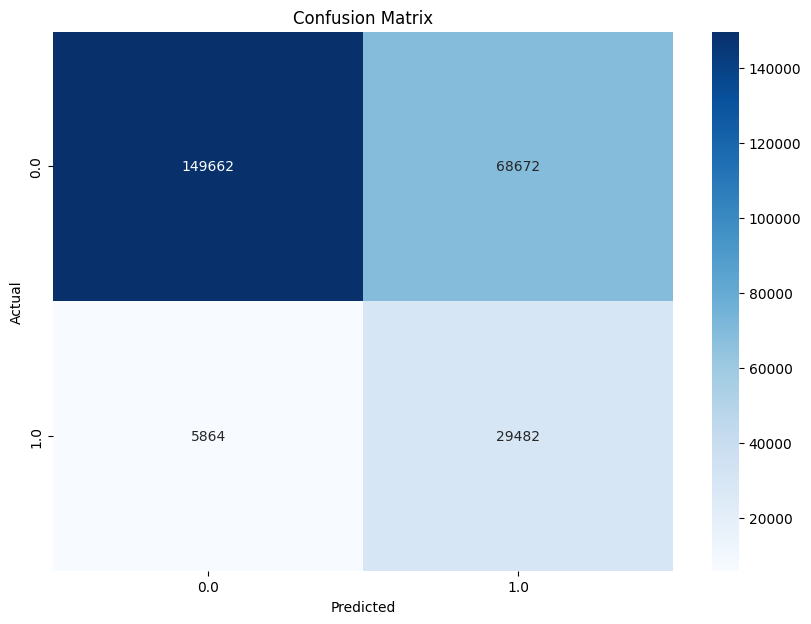

In [4]:
# evaluate the model
print(classification_report(y_test, y_pred))
# plot the confusion matrix

plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Modelling with pipelines

Using gridsearch and train_test_split to find optimal k-neighbours

In [5]:
# using 50/50 split and train test split
diabetes_dataframe = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

# split the data into features and target variable
X = diabetes_dataframe.drop('Diabetes_binary', axis=1)
y = diabetes_dataframe['Diabetes_binary']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# initialize pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# set up the parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# initialize grid search
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

# fit the model
grid.fit(X_train, y_train)

# best parameters
print("Best Parameters: ", grid.best_params_)
print("Best Cross-Validation Validation Score: ", grid.best_score_)

Best Parameters:  {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best Cross-Validation Validation Score:  0.7248774347889947


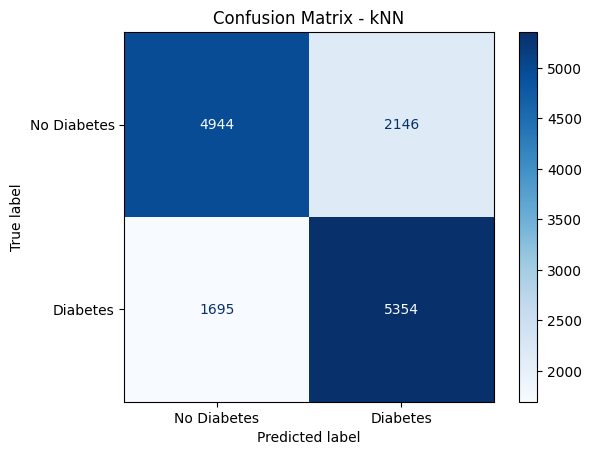

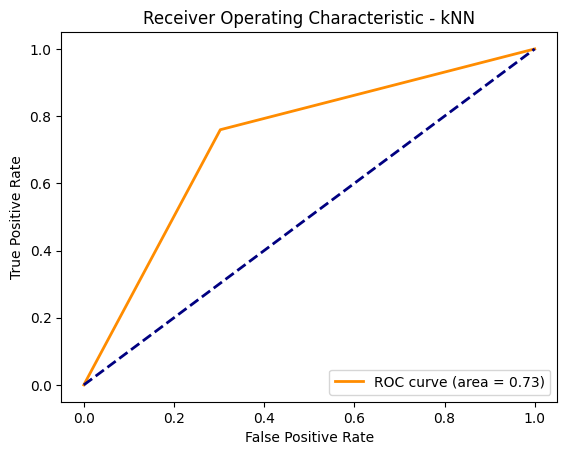

In [7]:
# make predictions
y_pred = grid.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

import matplotlib.pyplot as plt

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Diabetes", "Diabetes"], cmap=plt.cm.Blues)
plt.title("Confusion Matrix - kNN")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic - kNN")
plt.legend(loc="lower right")
plt.show()

Let's try pipelines again, but with the same data split strategy as in the first model made.

In [8]:
# split the trainging and testing data into features and target variable
X_train = diabetes_dataframe_training.drop('Diabetes_binary', axis=1)
y_train = diabetes_dataframe_training['Diabetes_binary']
X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

Best Parameters:  {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best Cross-Validation Validation Score:  0.7237595525483697
              precision    recall  f1-score   support

         0.0       0.96      0.70      0.81    218334
         1.0       0.31      0.80      0.44     35346

    accuracy                           0.72    253680
   macro avg       0.63      0.75      0.63    253680
weighted avg       0.87      0.72      0.76    253680



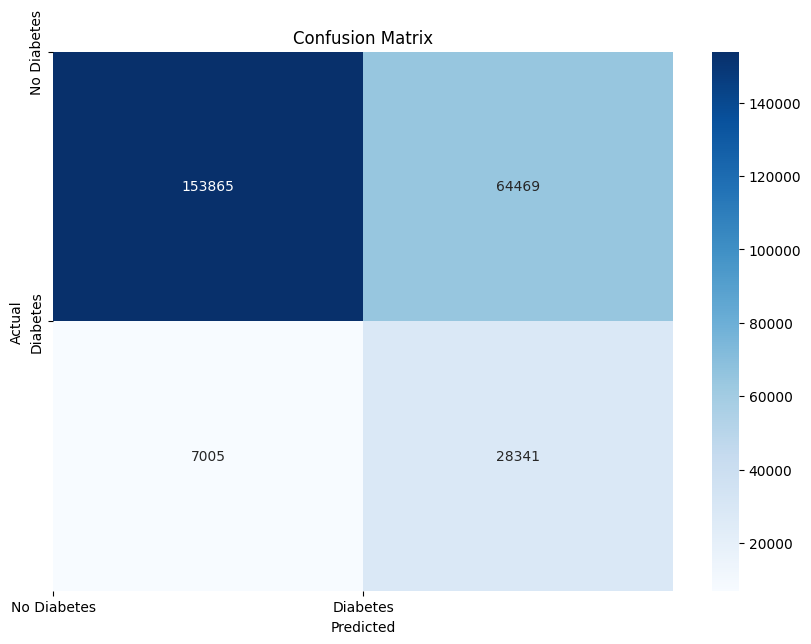

In [9]:
# we can use the same pipeline and grid search from before
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

# fit the model
grid.fit(X_train, y_train)
# best parameters
print("Best Parameters: ", grid.best_params_)
print("Best Cross-Validation Validation Score: ", grid.best_score_)

# make predictions
y_pred = grid.predict(X_test)

# evaluate the model
print(classification_report(y_test, y_pred))

# plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.yticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()